# 05 · Model Evaluation
**Ninja Van Capstone 2026 — Last-Mile Delivery Failure Prediction**

This notebook:
1. Loads all three trained models and applies them to the held-out test set
2. Computes AUC-ROC, Precision, Recall, F1, Brier score + confusion matrices
3. Plots ROC curves, feature importance, and calibration curves
4. Selects the champion model (best F1, AUC-ROC as tiebreaker)
5. Writes `evaluation_report.json` and copies champion model to `champion_model.joblib`

**Outputs:**
- `/content/outputs/evaluation_report.json`
- `/content/outputs/champion_model.joblib`
- `/content/outputs/roc_curves.png`
- `/content/outputs/confusion_matrices.png`
- `/content/outputs/feature_importance.png`
- `/content/outputs/calibration_curves.png`

> **Run order:** Final notebook — run after `04_model_training.ipynb`.


## 1 · Setup & Load Test Data

In [ ]:
import sys, json, joblib, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Locate repo root portably — works from notebooks/ in VS Code or Colab
REPO_DIR = Path.cwd()
while not (REPO_DIR / "config" / "config.yaml").exists():
    parent = REPO_DIR.parent
    if parent == REPO_DIR:
        raise RuntimeError("Cannot find repo root — run the notebook from inside the repo")
    REPO_DIR = parent

if str(REPO_DIR / "src") not in sys.path:
    sys.path.insert(0, str(REPO_DIR / "src"))

import yaml
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")          # non-interactive backend — safe in VS Code and headless
import matplotlib.pyplot as plt
from IPython.display import display, Image

PROC_DIR = REPO_DIR / "data" / "processed"
OUT_DIR  = REPO_DIR / "outputs"

with open(REPO_DIR / "config" / "config.yaml") as f:
    cfg = yaml.safe_load(f)

TARGET_COL = cfg["features"]["target_col"]
THRESHOLD  = 0.5

# Load test split
test_df = pd.read_parquet(PROC_DIR / "features_test.parquet")
X_test_raw = test_df.drop(columns=[TARGET_COL])
y_test     = test_df[TARGET_COL].astype(int).values

# Load feature names
with open(OUT_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

print(f"REPO_DIR : {REPO_DIR}")
print(f"PROC_DIR : {PROC_DIR}")
print(f"OUT_DIR  : {OUT_DIR}")
print(f"Test set : {len(test_df):,} rows  |  failure rate: {y_test.mean():.4f}")
print(f"Features : {len(feature_names)}")

In [2]:
# Load preprocessor and transform test set
preprocessor = joblib.load(OUT_DIR / "preprocessor.joblib")
X_test = preprocessor.transform(X_test_raw)
print(f"Transformed test set shape: {X_test.shape}")

Transformed test set shape: (902933, 20)


## 2 · Load All Trained Models

In [3]:
models = {}
for name in ["lgbm", "rf", "lr"]:
    path = OUT_DIR / f"model_{name}.joblib"
    if path.exists():
        models[name] = joblib.load(path)
        print(f"✅ Loaded {name:5s} → {path.name}")
    else:
        print(f"❌ {path} not found — skipping")

if not models:
    raise FileNotFoundError(
        "No trained models found in outputs/. Run 04_model_training.ipynb first."
    )

✅ Loaded lgbm  → model_lgbm.joblib
✅ Loaded rf    → model_rf.joblib
✅ Loaded lr    → model_lr.joblib


## 3 · Evaluate Each Model on Test Set

In [4]:
from evaluate import evaluate_model

results = {}
for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Evaluating: {name.upper()}")
    results[name] = evaluate_model(
        model, X_test, y_test,
        model_name=name,
        threshold=THRESHOLD,
        feature_names=feature_names,
    )


  Evaluating: LGBM

───────────────────────────────────────────────────────
                         LGBM                        
───────────────────────────────────────────────────────
  AUC-ROC : 0.6993
  Precision (failure): 0.1919
  Recall    (failure): 0.3822
  F1        (failure): 0.2555
  Brier score        : 0.1643

  Classification Report:
              precision    recall  f1-score   support

     success       0.93      0.84      0.88    821937
     failure       0.19      0.38      0.26     80996

    accuracy                           0.80    902933
   macro avg       0.56      0.61      0.57    902933
weighted avg       0.87      0.80      0.83    902933


  Evaluating: RF

───────────────────────────────────────────────────────
                          RF                         
───────────────────────────────────────────────────────
  AUC-ROC : 0.7629
  Precision (failure): 0.1870
  Recall    (failure): 0.6767
  F1        (failure): 0.2930
  Brier score        : 0.19

## 4 · ROC Curves

✅ ROC curves saved → /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/roc_curves.png


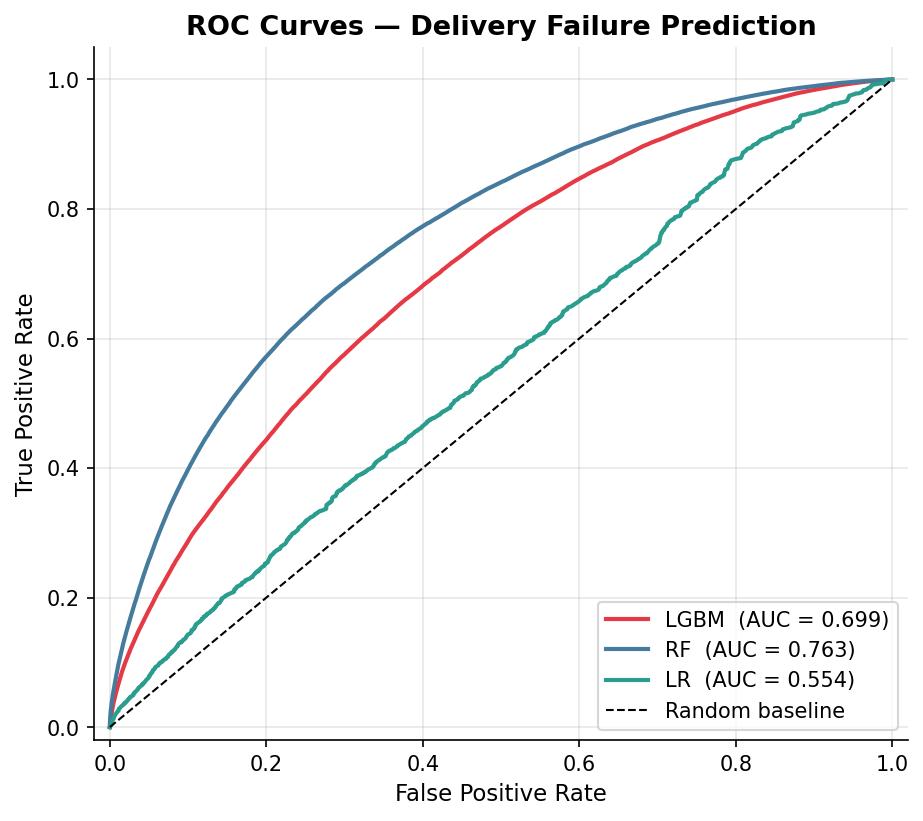

In [5]:
from evaluate import plot_roc_curves

roc_path = str(OUT_DIR / "roc_curves.png")
plot_roc_curves(models, results, y_test, save_path=roc_path)

from IPython.display import Image
Image(roc_path)

## 5 · Confusion Matrices

✅ Confusion matrices saved → /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/confusion_matrices.png


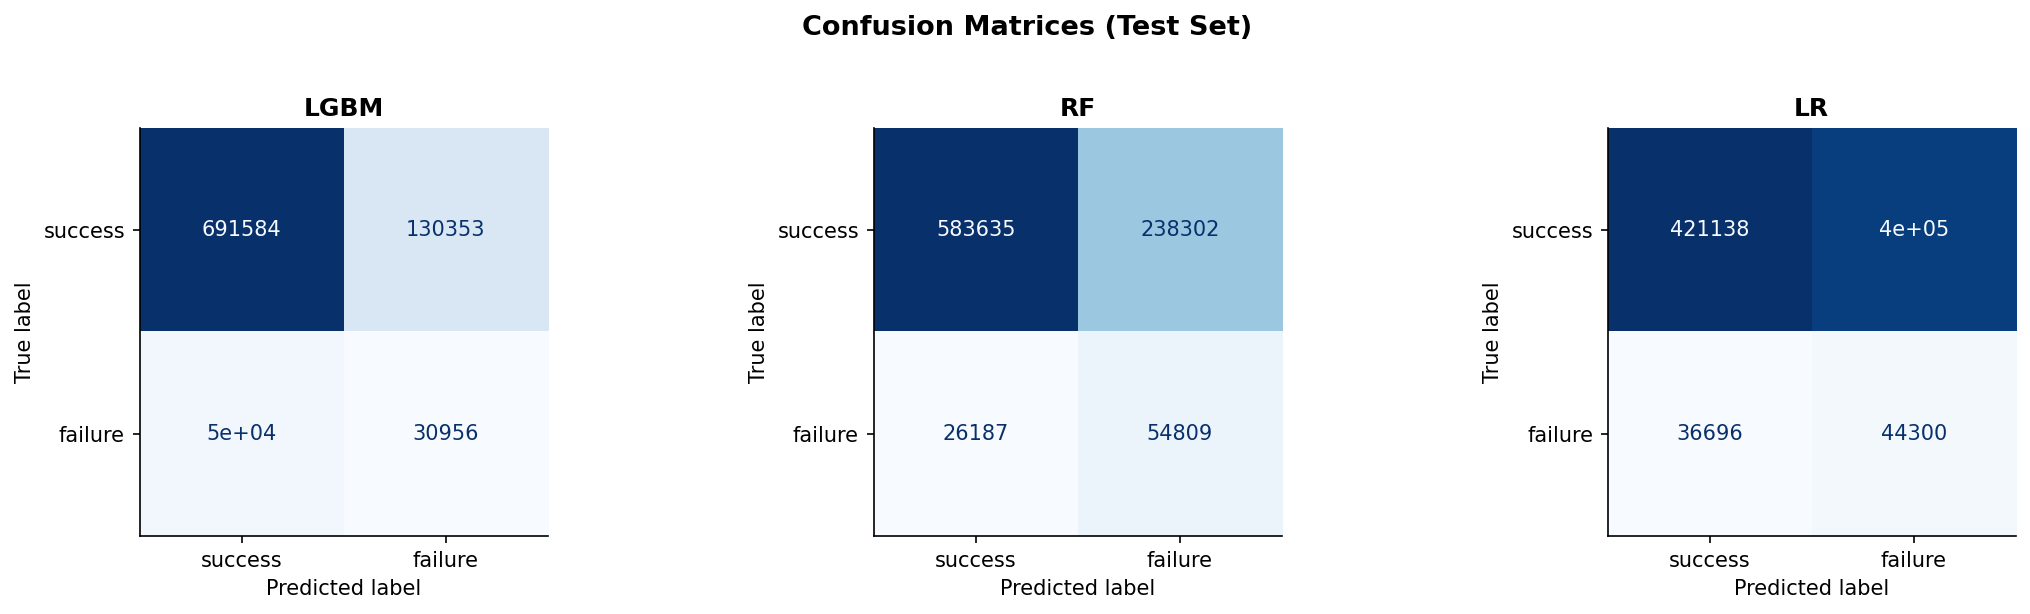

In [6]:
from evaluate import plot_confusion_matrices

cm_path = str(OUT_DIR / "confusion_matrices.png")
plot_confusion_matrices(results, save_path=cm_path)

Image(cm_path)

## 6 · LightGBM Feature Importance

In [7]:
from evaluate import plot_feature_importance

if "lgbm" in models:
    fi_path = str(OUT_DIR / "feature_importance.png")
    plot_feature_importance(
        models["lgbm"],
        feature_names=feature_names,
        save_path=fi_path,
        top_n=20,
    )
    Image(fi_path)
else:
    print("⚠️  LightGBM model not available — skipping feature importance plot")

✅ Feature importance plot saved → /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/feature_importance.png


## 7 · Calibration Curves

✅ Calibration curves saved → /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/calibration_curves.png


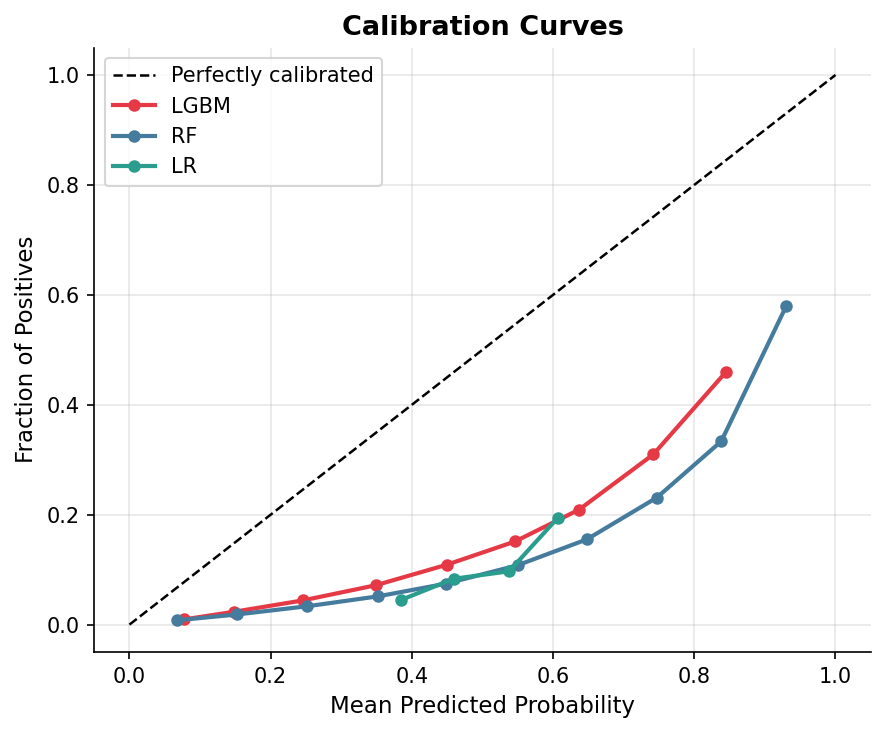

In [8]:
from evaluate import plot_calibration_curves

cal_path = str(OUT_DIR / "calibration_curves.png")
plot_calibration_curves(results, y_test, save_path=cal_path)

Image(cal_path)

## 8 · Metric Summary Table

In [9]:
summary_rows = []
for name, res in results.items():
    summary_rows.append({
        "Model":     name.upper(),
        "AUC-ROC":   f"{res['auc_roc']:.4f}",
        "Precision": f"{res['precision']:.4f}",
        "Recall":    f"{res['recall']:.4f}",
        "F1":        f"{res['f1']:.4f}",
        "Brier":     f"{res['brier']:.4f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print("\n" + "=" * 65)
print("  TEST SET EVALUATION SUMMARY")
print("=" * 65)
print(summary_df.to_string())
print("=" * 65)


  TEST SET EVALUATION SUMMARY
      AUC-ROC Precision  Recall      F1   Brier
Model                                          
LGBM   0.6993    0.1919  0.3822  0.2555  0.1643
RF     0.7629    0.1870  0.6767  0.2930  0.1970
LR     0.5540    0.0995  0.5469  0.1684  0.2474


## 9 · Select Champion Model

In [10]:
from evaluate import select_champion

champion = select_champion(results)
print(f"\n🏆 Champion model: {champion.upper()}")


📊 Model Ranking (by F1, then AUC-ROC):
  Model            F1   AUC-ROC   Precision   Recall
  ──────────  ───────  ────────  ──────────  ───────
  rf           0.2930    0.7629      0.1870   0.6767 ← CHAMPION
  lgbm         0.2555    0.6993      0.1919   0.3822
  lr           0.1684    0.5540      0.0995   0.5469

🏆 Champion model: RF


## 10 · Write Evaluation Report & Copy Champion

In [11]:
from evaluate import write_evaluation_report, copy_champion_model

report = write_evaluation_report(
    results=results,
    champion=champion,
    feature_names=feature_names,
    test_set_size=len(y_test),
    failure_rate_test=float(y_test.mean()),
    save_path=str(OUT_DIR / "evaluation_report.json"),
    threshold=THRESHOLD,
)

champion_path = copy_champion_model(champion, str(OUT_DIR))

print("\n📋 Evaluation Report:")
print(json.dumps(report, indent=2, default=float))

✅ Evaluation report saved → /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/evaluation_report.json
✅ Champion model copied: model_rf.joblib → champion_model.joblib

📋 Evaluation Report:
{
  "champion_model": "rf",
  "models": {
    "lgbm": {
      "auc_roc": 0.699311,
      "precision": 0.191905,
      "recall": 0.382192,
      "f1": 0.255513,
      "brier": 0.164254
    },
    "rf": {
      "auc_roc": 0.762941,
      "precision": 0.186991,
      "recall": 0.676688,
      "f1": 0.293012,
      "brier": 0.196995
    },
    "lr": {
      "auc_roc": 0.553967,
      "precision": 0.099528,
      "recall": 0.546941,
      "f1": 0.168411,
      "brier": 0.24742
    }
  },
  "test_set_size": 902933,
  "failure_rate_test": 0.089703,
  "feature_names": [
    "hour_of_day",
    "day_of_week",
    "days_since_order",
    "time_window_duration_mins",
    "time_window_start_hour",
    "time_window_end_hour",
    "courier_daily_parcel_count",
    "courier_hi

## 11 · Artifact Summary

In [12]:
artifacts = [
    OUT_DIR / "champion_model.joblib",
    OUT_DIR / "preprocessor.joblib",
    OUT_DIR / "model_lgbm.joblib",
    OUT_DIR / "model_rf.joblib",
    OUT_DIR / "model_lr.joblib",
    OUT_DIR / "feature_names.json",
    OUT_DIR / "evaluation_report.json",
]

print("Artifacts:")
for path in artifacts:
    status = "✅" if path.exists() else "❌ missing"
    print(f"  {status}  {path}")

Artifacts:
  ✅  /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/champion_model.joblib
  ✅  /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/preprocessor.joblib
  ✅  /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/model_lgbm.joblib
  ✅  /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/model_rf.joblib
  ✅  /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/model_lr.joblib
  ✅  /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/feature_names.json
  ✅  /home/tashrif/ninja-van/last-mile-delivery-failure-prediction/nv-lastmile-training/outputs/evaluation_report.json


In [ ]:
print("=" * 70)
print("  NOTEBOOK 05 COMPLETE — TRAINING PIPELINE FINISHED")
print("=" * 70)
print()
print("  Artifacts produced:")
print(f"    champion_model.joblib  → {OUT_DIR / 'champion_model.joblib'}")
print(f"    preprocessor.joblib   → {OUT_DIR / 'preprocessor.joblib'}")
print(f"    model_lgbm.joblib     → {OUT_DIR / 'model_lgbm.joblib'}")
print(f"    model_rf.joblib       → {OUT_DIR / 'model_rf.joblib'}")
print(f"    model_lr.joblib       → {OUT_DIR / 'model_lr.joblib'}")
print(f"    feature_names.json    → {OUT_DIR / 'feature_names.json'}")
print(f"    evaluation_report.json→ {OUT_DIR / 'evaluation_report.json'}")
print()
print("  Next step: Copy joblib files to nv-lastmile-demo/models/")
print("             to power the Gradio POC app.")
print("=" * 70)